In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

2023-12-31 14:17:06.263139: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2023-12-31 14:17:06.300904: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-12-31 14:17:06.300952: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-12-31 14:17:06.301775: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-12-31 14:17:06.308271: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2023-12-31 14:17:06.309986: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [4]:
df = pd.read_csv('/home/alvaro/tf_templates/DATA/breast-cancer.csv')
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

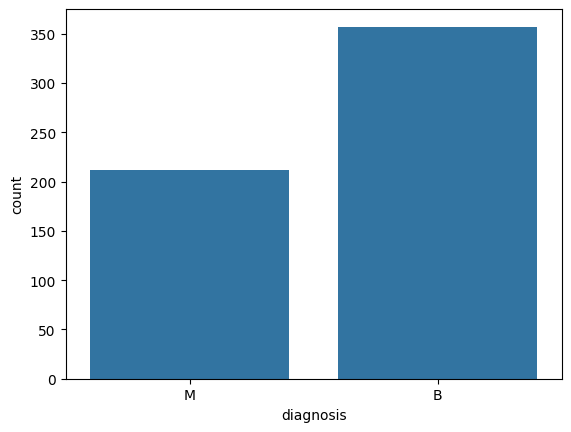

In [6]:
sns.countplot(data=df, x='diagnosis');

In [7]:
df['diagnosis'] = df['diagnosis'].map({'M':1,'B':0})

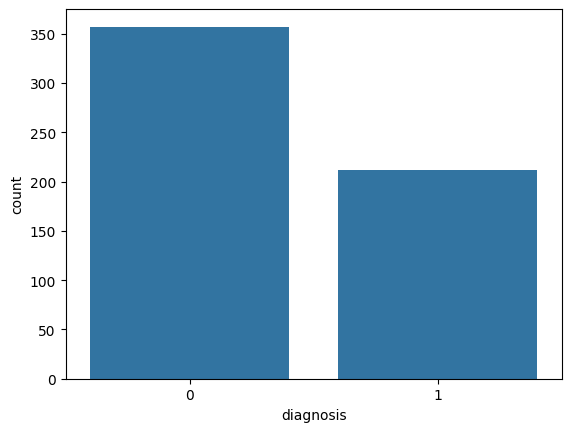

In [8]:
sns.countplot(data=df,x='diagnosis');

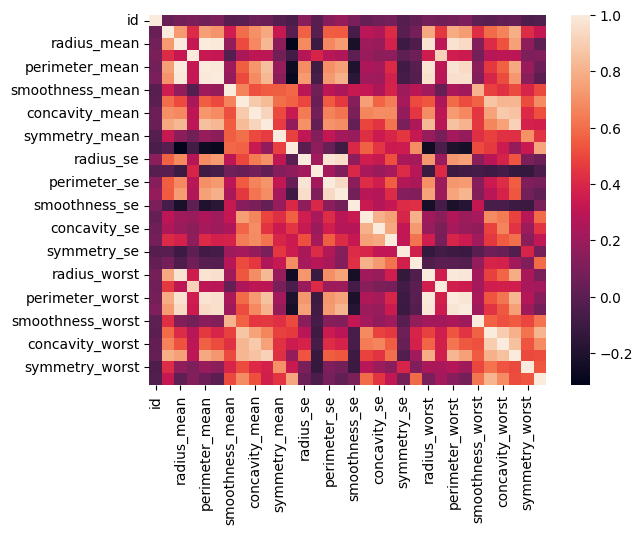

In [9]:
sns.heatmap(df.corr());

In [10]:
df.corr()['diagnosis'].sort_values()

smoothness_se             -0.067016
fractal_dimension_mean    -0.012838
texture_se                -0.008303
symmetry_se               -0.006522
id                         0.039769
fractal_dimension_se       0.077972
concavity_se               0.253730
compactness_se             0.292999
fractal_dimension_worst    0.323872
symmetry_mean              0.330499
smoothness_mean            0.358560
concave points_se          0.408042
texture_mean               0.415185
symmetry_worst             0.416294
smoothness_worst           0.421465
texture_worst              0.456903
area_se                    0.548236
perimeter_se               0.556141
radius_se                  0.567134
compactness_worst          0.590998
compactness_mean           0.596534
concavity_worst            0.659610
concavity_mean             0.696360
area_mean                  0.708984
radius_mean                0.730029
area_worst                 0.733825
perimeter_mean             0.742636
radius_worst               0

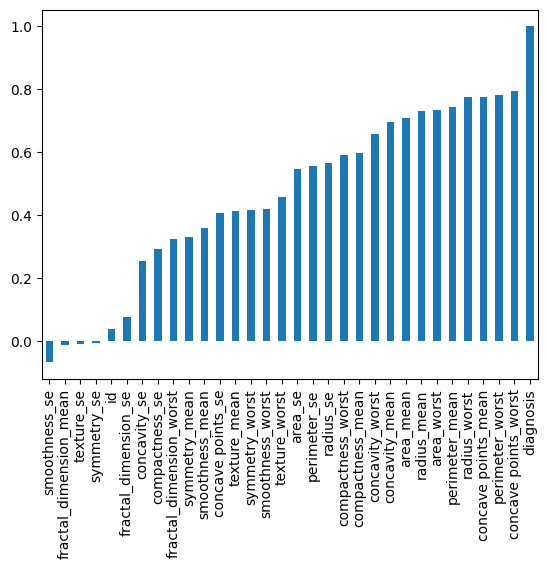

In [11]:
df.corr()['diagnosis'].sort_values().plot(kind='bar');

In [12]:
x = df.drop('diagnosis', axis=1).values
y = df['diagnosis'].values

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

In [14]:
scaler = MinMaxScaler()

In [15]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [16]:
x_train.shape

(398, 31)

In [17]:
model = Sequential()

model.add(Dense(units=30, activation='relu'))
model.add(Dropout(rate=0.5))
model.add(Dense(units=15, activation='relu'))
model.add(Dropout(rate=0.5))
model.add(Dense(units=1, activation='sigmoid'))

In [18]:
model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])

In [19]:
early_stop = EarlyStopping(monitor='val_loss', patience=25)

In [20]:
model.fit(
    x=x_train, y=y_train,
    batch_size=None,
    epochs=400,
    callbacks=[early_stop],
    validation_data=(x_test,y_test)
)

Epoch 1/400
13/13 [==============================] - 1s 16ms/step - loss: 0.7057 - accuracy: 0.5176 - val_loss: 0.6875 - val_accuracy: 0.5848
Epoch 2/400
13/13 [==============================] - 0s 10ms/step - loss: 0.6946 - accuracy: 0.5879 - val_loss: 0.6785 - val_accuracy: 0.6023
Epoch 3/400
13/13 [==============================] - 0s 6ms/step - loss: 0.6756 - accuracy: 0.6106 - val_loss: 0.6636 - val_accuracy: 0.6725
Epoch 4/400
13/13 [==============================] - 0s 7ms/step - loss: 0.6534 - accuracy: 0.6558 - val_loss: 0.6440 - val_accuracy: 0.7895
Epoch 5/400
13/13 [==============================] - 0s 6ms/step - loss: 0.6299 - accuracy: 0.7010 - val_loss: 0.6252 - val_accuracy: 0.7719
Epoch 6/400
13/13 [==============================] - 0s 6ms/step - loss: 0.6196 - accuracy: 0.6834 - val_loss: 0.6041 - val_accuracy: 0.7836
Epoch 7/400
13/13 [==============================] - 0s 6ms/step - loss: 0.6018 - accuracy: 0.7412 - val_loss: 0.5765 - val_accuracy: 0.8304
Epoch 8/400

In [21]:
losses = pd.DataFrame(model.history.history)

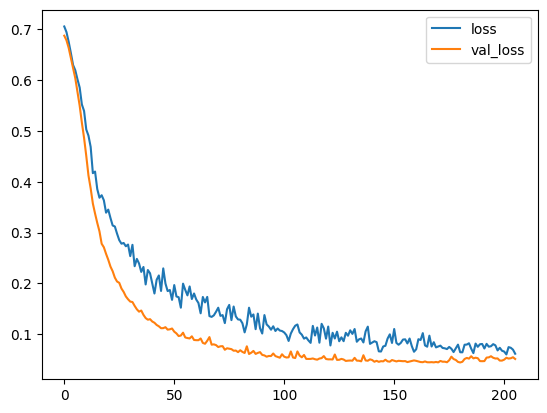

In [22]:
losses[['loss','val_loss']].plot();

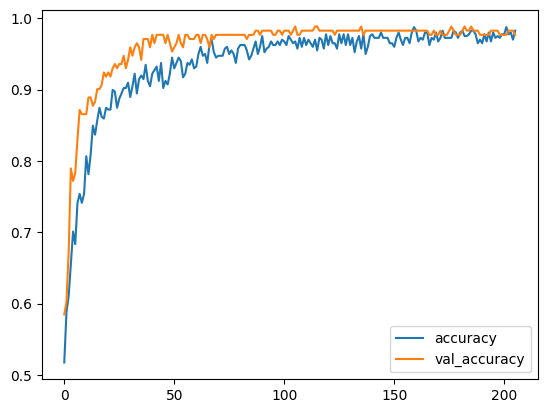

In [23]:
losses[['accuracy','val_accuracy']].plot();

In [24]:
predictions = (model.predict(x_test) > 0.5).astype('int32')

6/6 [==============================] - 0s 2ms/step


In [25]:
# https://en.wikipedia.org/wiki/Precision_and_recall
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       100
           1       0.97      0.97      0.97        71

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



<Axes: >

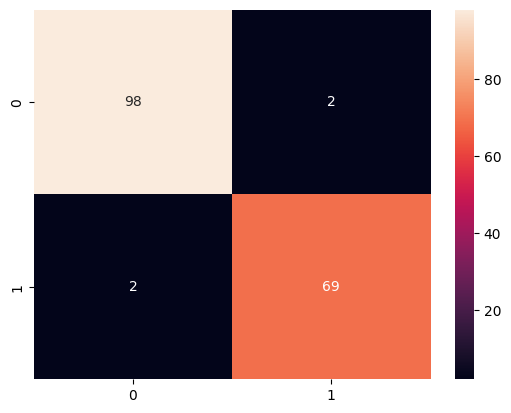

In [26]:
sns.heatmap(confusion_matrix(y_test, predictions), annot=True)

In [27]:
prediction = (model.predict(x_test[[0]]) > 0.5).astype('int32')
prediction

1/1 [==============================] - 0s 18ms/step


array([[0]], dtype=int32)

In [28]:
y_test[[0]]

array([0])